### E bem-vindo à Semana 4, Dia 3 - mais LangGraph..

In [1]:
from typing import Annotated
from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages
from dotenv import load_dotenv
from IPython.display import Image, display
import gradio as gr
from langgraph.prebuilt import ToolNode, tools_condition
import requests
import os
from langchain_openai import ChatOpenAI
from typing import TypedDict


In [2]:
# Nosso primeiro passo favorito! Aliás, o Crew fazia isso por nós.
load_dotenv(override=True)


True

### Primeiro, vamos configurar o LangSmith!

https://langsmith.com

### Em seguida, aqui está uma função útil na comunidade LangChain:

In [3]:
from langchain_community.utilities import GoogleSerperAPIWrapper

serper = GoogleSerperAPIWrapper()
serper.run("Qual é a capital da França?")

'Paris is the capital and largest city of France, with an estimated city center population of 2,048,472, and a metropolitan area of 13,171,056 as of January ... Paris é a capital econômica e comercial da França, onde os negócios da Bolsa e das finanças se concentram. A densidade da sua rede ferroviária, rodoviária e da ... Tem como capital a cidade de Paris. 2- Possui cinco territórios ultramarinos, que ficam nas Américas do Sul e Central, na África e no Oceano ... Paris is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. Paris fica na região de Île de France, possui 2.275 milhões de habitantes e é a capital francesa desde o ano de 508 D.C. A cidade recebe 47 milhões de ... Capital: Paris ; Língua oficial da UE: francês ; Adesão à UE: 1 de janeiro de 1958 ; Moeda: euro (€) ; Área do euro: membro desde 1 de janeiro de 1999. Dive into the charm of Paris, the capital of France! Explore its rich h

### Agora, aqui está uma classe wrapper do LangChain para converter funções em ferramentas

In [4]:
from langchain.agents import Tool

tool_search =Tool(
        name="search",
        func=serper.run,
        description="Útil quando você precisa de mais informações de uma busca online"
    )



### Agora podemos experimentar a ferramenta ao estilo LangChain

In [5]:
tool_search.invoke("Qual é a capital da França?")

'Paris is the capital and largest city of France, with an estimated city center population of 2,048,472, and a metropolitan area of 13,171,056 as of January ... Paris é a capital econômica e comercial da França, onde os negócios da Bolsa e das finanças se concentram. A densidade da sua rede ferroviária, rodoviária e da ... Tem como capital a cidade de Paris. 2- Possui cinco territórios ultramarinos, que ficam nas Américas do Sul e Central, na África e no Oceano ... Paris is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants). Paris has 2.234 million inhabitants end 2011. Capital: Paris ; Língua oficial da UE: francês ; Adesão à UE: 1 de janeiro de 1958 ; Moeda: euro (€) ; Área do euro: membro desde 1 de janeiro de 1999. Paris fica na região de Île de France, possui 2.275 milhões de habitantes e é a capital francesa desde o ano de 508 D.C. A cidade recebe 47 milhões de ... France, country of northwestern Europe. Historically and culturally amo

### E agora vamos escrever uma ferramenta nós mesmos

Vamos escolher uma conhecida

In [6]:
pushover_token = os.getenv("PUSHOVER_TOKEN")
pushover_user = os.getenv("PUSHOVER_USER")
pushover_url = "https://api.pushover.net/1/messages.json"

def push(text: str):
    """Enviar uma notificação push para o usuário"""
    requests.post(pushover_url, data = {"token": pushover_token, "user": pushover_user, "message": text})

In [7]:
tool_push = Tool(
        name="send_push_notification",
        func=push,
        description="útil quando você quer enviar uma notificação push"
    )

tool_push.invoke("Olá, eu")

### De volta ao grafo de ontem

Uma pequena mudança - usar TypedDict em vez de BaseModel para o objeto State

Quando implementamos ferramentas, precisamos sempre fazer 2 mudanças no código:

1. Mudanças para fornecer as ferramentas para a OpenAI em JSON quando fazemos a chamada

2. Mudanças para lidar com os resultados de volta: verificar se o modelo indica que finish_reason=="tool_calls" e então recuperar a chamada, executar a função e fornecer os resultados.

### Junte tudo

In [8]:
tools = [tool_search, tool_push]

In [9]:
# Etapa 1: definir o objeto State
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [10]:
# Etapa 2: iniciar o construtor do grafo com esta classe State
graph_builder = StateGraph(State)

In [12]:
# Isto é diferente:

llm = ChatOpenAI(model="gpt-5-mini")
llm_with_tools = llm.bind_tools(tools)

In [13]:
# Etapa 3: criar um nó


def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

In [14]:
# Etapa 4: criar arestas


graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")

# Sempre que uma ferramenta for chamada, retornamos ao chatbot para decidir o próximo passo
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

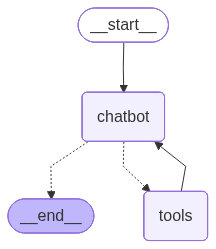

In [15]:
# Etapa 5: compilar o grafo
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

### É isso! E vamos fazer o seguinte:

In [16]:
def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]})
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## Certo, é hora de adicionar memória!

### MAS ESPERE!

Temos todo esse Grafo mantendo o estado e anexando ao estado.

Por que isso não está lidando com a memória?

### Este é um ponto crucial para entender o LangGraph

> Um super-step pode ser considerado uma única iteração sobre os nós do grafo. Nós que executam em paralelo fazem parte do mesmo super-step, enquanto nós que executam sequencialmente pertencem a super-steps separados.


Um "Super-Step" do grafo representa uma invocação de passagem de mensagens entre agentes.

No LangGraph idiomático, você chama invoke para executar seu grafo a cada super-step; para cada interação.

O reducer lida com as atualizações de estado automaticamente dentro de um super-step, mas não entre eles.

É isso que o checkpointing proporciona.

In [17]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

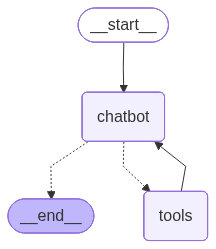

In [19]:
# Etapas 1 e 2
graph_builder = StateGraph(State)


# Etapa 3
llm = ChatOpenAI(model="gpt-5-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Etapa 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Etapa 5
graph = graph_builder.compile(checkpointer=memory)
display(Image(graph.get_graph().draw_mermaid_png()))

In [29]:
config = {"configurable": {"thread_id": "1"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='do que estavamos falando?', additional_kwargs={}, response_metadata={}, id='7421bcbb-7877-47b3-ba95-bd1d299bad00')]}


In [24]:
graph.get_state(config)

StateSnapshot(values={'messages': [HumanMessage(content='oi', additional_kwargs={}, response_metadata={}, id='4b42319b-4e8c-4356-a252-a9c96090a12a'), AIMessage(content='Oi! Como posso ajudar você hoje? Quer tirar uma dúvida, conversar ou precisa de ajuda com algo específico?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 170, 'total_tokens': 265, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CJW8AHEWW2lYpaRsQDBXNgF5iNPbD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--eb5e343d-b78d-47f6-888c-0b5e5cae9074-0', usage_metadata={'input_tokens': 170, 'output_tokens': 95, 'total_tokens': 265, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outpu

In [25]:
# Mais recente primeiro

list(graph.get_state_history(config))

[StateSnapshot(values={'messages': [HumanMessage(content='oi', additional_kwargs={}, response_metadata={}, id='4b42319b-4e8c-4356-a252-a9c96090a12a'), AIMessage(content='Oi! Como posso ajudar você hoje? Quer tirar uma dúvida, conversar ou precisa de ajuda com algo específico?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 95, 'prompt_tokens': 170, 'total_tokens': 265, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CJW8AHEWW2lYpaRsQDBXNgF5iNPbD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--eb5e343d-b78d-47f6-888c-0b5e5cae9074-0', usage_metadata={'input_tokens': 170, 'output_tokens': 95, 'total_tokens': 265, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'outp

### O LangGraph oferece ferramentas para restaurar o estado a um ponto anterior no tempo, para ramificar:

```
config = {"configurable": {"thread_id": "1", "checkpoint_id": ...}}
graph.invoke(None, config=config)
```

E isso permite construir sistemas estáveis que podem ser recuperados e executados novamente a partir de qualquer checkpoint anterior.

### E agora vamos armazenar em SQL

### E esse é o poder do LangGraph.

In [26]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

db_path = "memory.db"
conn = sqlite3.connect(db_path, check_same_thread=False)
sql_memory = SqliteSaver(conn)

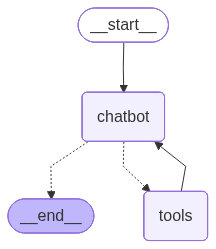

In [27]:
# Etapas 1 e 2
graph_builder = StateGraph(State)


# Etapa 3
llm = ChatOpenAI(model="gpt-5-mini")
llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    print(state)
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)
graph_builder.add_node("tools", ToolNode(tools=tools))

# Etapa 4
graph_builder.add_conditional_edges( "chatbot", tools_condition, "tools")
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

# Etapa 5
graph = graph_builder.compile(checkpointer=sql_memory)
display(Image(graph.get_graph().draw_mermaid_png()))
 

In [28]:
config = {"configurable": {"thread_id": "3"}}

def chat(user_input: str, history):
    result = graph.invoke({"messages": [{"role": "user", "content": user_input}]}, config=config)
    return result["messages"][-1].content


gr.ChatInterface(chat, type="messages").launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.


{'messages': [HumanMessage(content='hi there', additional_kwargs={}, response_metadata={}, id='d6144090-9963-438c-b21b-3fb4f06edbc0'), AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 90, 'total_tokens': 101, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_b376dfbbd5', 'id': 'chatcmpl-BInN7JUnEYNTQqokCF3eihp5oKP0V', 'finish_reason': 'stop', 'logprobs': None}, id='run-4b488710-73ac-435e-a944-913a0c812d08-0', usage_metadata={'input_tokens': 90, 'output_tokens': 11, 'total_tokens': 101, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMessage(content="what's my name", additional_kwargs